#                   ***Logistic Regression Model***

Step 1: Upload file in Google Colab

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving body_mass_index_dataset.xlsx to body_mass_index_dataset.xlsx


Step 2: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Step 3: Load the Data into a DataFrame

In [ ]:
df = pd.read_excel(list(uploaded.keys())[0]) #Load the uploaded Excel file into a pandas DataFrame.
df.head(10)

,person_id,age,gender,height_cm,weight_kg,physical_activity_level,daily_calorie_intake,smoking_status,alcohol_consumption,family_history_obesity,bmi,bmi_category
0,1,56,Female,164.3,86.3,Low,2584,Smoker,High,No,31.97,Obese
1,2,69,Male,177.0,64.1,Moderate,1706,Non-smoker,Moderate,No,20.46,Normal
2,3,46,Male,151.8,94.0,Moderate,2292,Non-smoker,Moderate,No,40.79,Obese
3,4,32,Male,165.1,75.7,High,2655,Non-smoker,NaN,No,27.77,Overweight
4,5,60,Female,172.3,83.9,Moderate,2376,Non-smoker,NaN,No,28.26,Overweight
5,6,25,Female,174.3,52.6,Low,3399,Non-smoker,NaN,Yes,17.31,Underweight
6,7,78,Female,172.3,81.9,High,2524,Non-smoker,Moderate,No,27.59,Overweight
7,8,38,Male,150.8,77.0,High,2051,Non-smoker,Moderate,No,33.86,Obese
8,9,56,Female,176.3,101.7,Moderate,1776,Non-smoker,NaN,No,32.72,Obese
9,10,75,Female,165.7,77.7,Low,2258,Non-smoker,High,Yes,28.30,Overweight


Step 4: Statistical Summary

In [ ]:
df.info() #check the structure of the dataset before analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   person_id                12000 non-null  int64  
 1   age                      12000 non-null  int64  
 2   gender                   12000 non-null  object 
 3   height_cm                12000 non-null  float64
 4   weight_kg                12000 non-null  float64
 5   physical_activity_level  12000 non-null  object 
 6   daily_calorie_intake     12000 non-null  int64  
 7   smoking_status           12000 non-null  object 
 8   alcohol_consumption      7154 non-null   object 
 9   family_history_obesity   12000 non-null  object 
 10  bmi                      12000 non-null  float64
 11  bmi_category             12000 non-null  object 
dtypes: float64(3), int64(3), object(6)
memory usage: 1.1+ MB


In [ ]:
df.shape #Helps to know the size of your dataset

(12000, 12)

In [ ]:
df.describe().round(2).T #Helps for quick statistical insights of the dataset

,count,mean,std,min,25%,50%,75%,max
person_id,12000.0,6000.50,3464.25,1.00,3000.75,6000.50,9000.25,12000.00
age,12000.0,48.70,17.88,18.00,33.00,49.00,64.00,79.00
height_cm,12000.0,165.01,9.95,120.20,158.20,165.00,171.80,206.50
weight_kg,12000.0,69.99,14.92,3.00,60.00,69.90,79.93,124.60
daily_calorie_intake,12000.0,2498.63,581.01,1500.00,1996.00,2500.00,3012.00,3499.00
bmi,12000.0,25.99,6.43,1.02,21.58,25.72,30.04,64.09


In [ ]:
df.isnull().sum()  #Helps to identify columns with missing data

,0
person_id,0
age,0
gender,0
height_cm,0
weight_kg,0
physical_activity_level,0
daily_calorie_intake,0
smoking_status,0
alcohol_consumption,4846
family_history_obesity,0


Note: The alcohol_consumption column shows 4846 missing values because the dataset contains None entries, which the code treats as missing. We need to handle these missing values.

In [ ]:
df['alcohol_consumption'].fillna(df['alcohol_consumption'].mode()[0], inplace=True)

#This fixes the missing values in alcohol_consumption by replacing them with the most common value which is None.

/tmp/ipython-input-2724927900.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_consumption'].fillna(df['alcohol_consumption'].mode()[0], inplace=True)


Now, if we rerun isnull() and info(), they will reflect the updated data and show that the missing values have been handled correctly.

Step 5: Create categorial variable from continuous variable

Transform the continuous BMI variable into a binary categorical variable, where BMI ≥ 30 is labeled as 1 (Obese) and BMI < 30 is labeled as 0 (Not Obese).

In [ ]:
df['obese'] = np.where(df['bmi'] >= 30, 1, 0) #Creates a new binary column based on BMI and Added this as a new column in the df
df.head()

,person_id,age,gender,height_cm,weight_kg,physical_activity_level,daily_calorie_intake,smoking_status,alcohol_consumption,family_history_obesity,bmi,bmi_category,obese
0,1,56,Female,164.3,86.3,Low,2584,Smoker,High,No,31.97,Obese,1
1,2,69,Male,177.0,64.1,Moderate,1706,Non-smoker,Moderate,No,20.46,Normal,0
2,3,46,Male,151.8,94.0,Moderate,2292,Non-smoker,Moderate,No,40.79,Obese,1
3,4,32,Male,165.1,75.7,High,2655,Non-smoker,Moderate,No,27.77,Overweight,0
4,5,60,Female,172.3,83.9,Moderate,2376,Non-smoker,Moderate,No,28.26,Overweight,0


Step 6: Exploratory Data Analysis (EDA)

In [ ]:
df.info()
#After creating the obese column, confirming it exists and has no missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   person_id                12000 non-null  int64  
 1   age                      12000 non-null  int64  
 2   gender                   12000 non-null  object 
 3   height_cm                12000 non-null  float64
 4   weight_kg                12000 non-null  float64
 5   physical_activity_level  12000 non-null  object 
 6   daily_calorie_intake     12000 non-null  int64  
 7   smoking_status           12000 non-null  object 
 8   alcohol_consumption      12000 non-null  object 
 9   family_history_obesity   12000 non-null  object 
 10  bmi                      12000 non-null  float64
 11  bmi_category             12000 non-null  object 
 12  obese                    12000 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 1.2+ MB


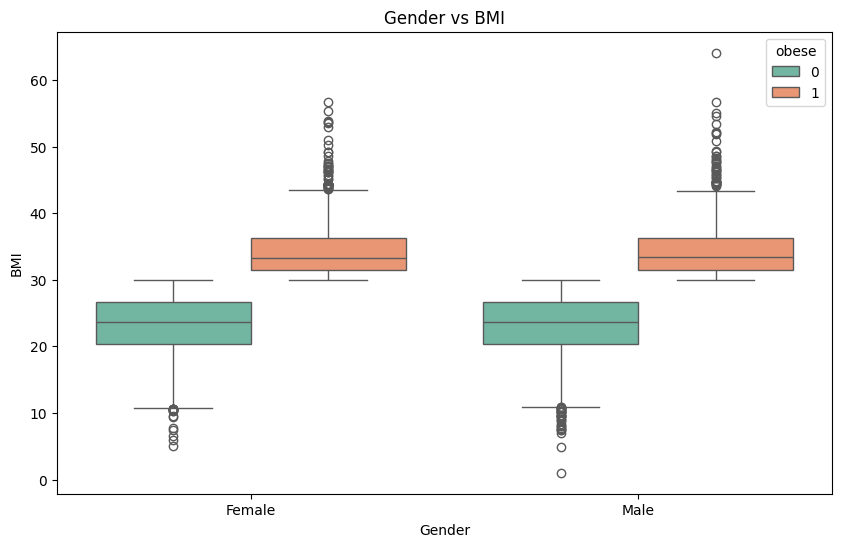

In [ ]:
# Gender vs BMI
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='bmi', data=df, hue='obese', palette='Set2') # Boxplot for BMI by Gender and Obese status
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.title('Gender vs BMI')
plt.show()

#Boxplot showing BMI distribution by gender, separated by obesity status.

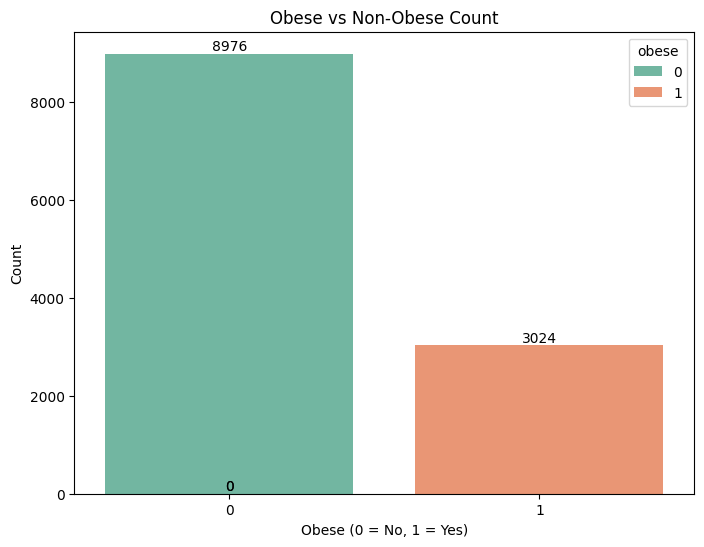

In [ ]:
# Obese vs Non-Obese Count
plt.figure(figsize=(8, 6))
bar_plot = sns.countplot(x='obese', data=df, palette='Set2', hue= 'obese')

#labelling the bars
for bar in bar_plot.patches:
    height = bar.get_height()
    bar_plot.text(x = bar.get_x() + bar.get_width()/2, y = height, s = f'{int(height)}', ha='center', va='bottom')

plt.xlabel('Obese (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Obese vs Non-Obese Count')
plt.show()

#Countplot showing the number of obese and non-obese individuals.

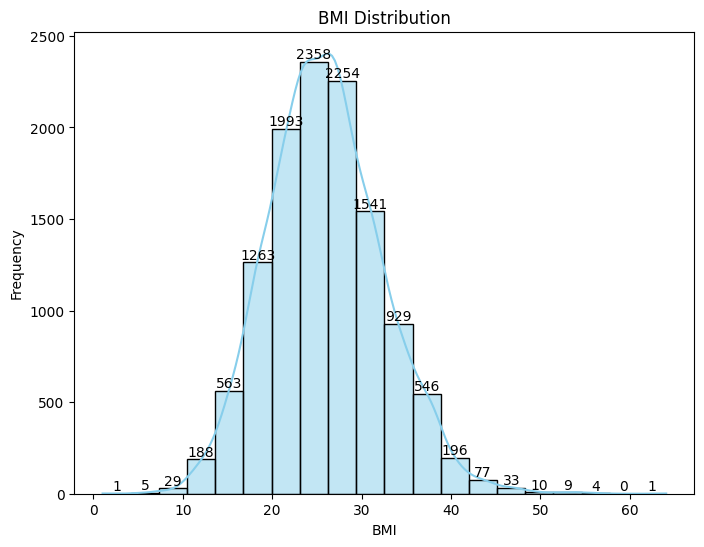

In [ ]:
# BMI distribution
plt.figure(figsize=(8, 6))
hist_plot = sns.histplot(df['bmi'], bins=20, kde=True, color='skyblue') #The range of BMI values in our dataset will be divided into 20 equal-width intervals.

#labelling the bars
for bar in hist_plot.patches:
    height = bar.get_height()
    hist_plot.text(x = bar.get_x() + bar.get_width()/2, y = height, s = f'{int(height)}', ha='center', va='bottom')

plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('BMI Distribution')
plt.show()

#Histogram showing the distribution of BMI with a KDE curve.

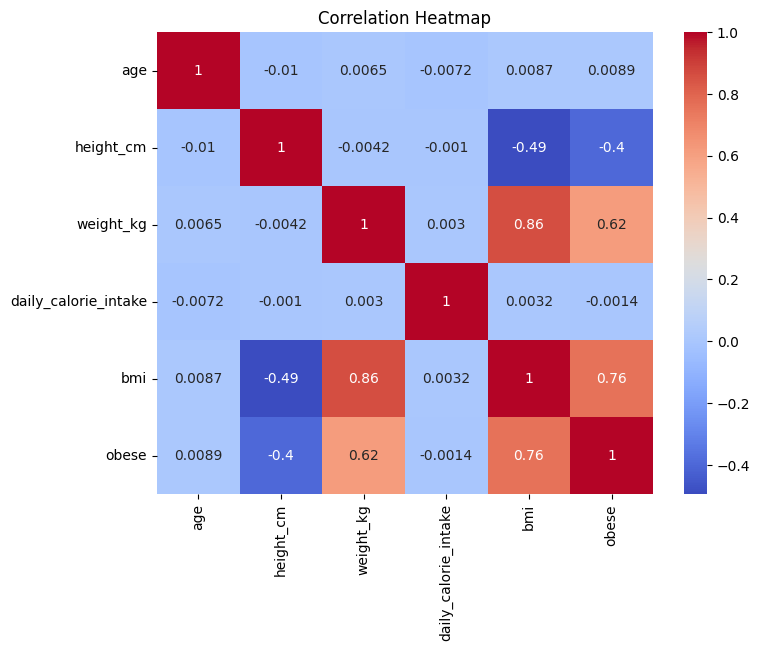

In [ ]:
# Correlation heatmap for the numerical columns
plt.figure(figsize=(8, 6))

numeric_columns = df.select_dtypes(include=[np.number]).drop(columns=['person_id']) #Because person_id is identifier and it is not making any sense in this plot

sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#Heatmap showing correlations between numerical features, excluding the identifier column.

A correlation measures how two variables move together and its value is always from -1 to 1.


*   1 means perfect positive correlation ie. both increase together
*   0 means no correlation
*  -1 means perfect negative correlation ie. one increase and other decrease.



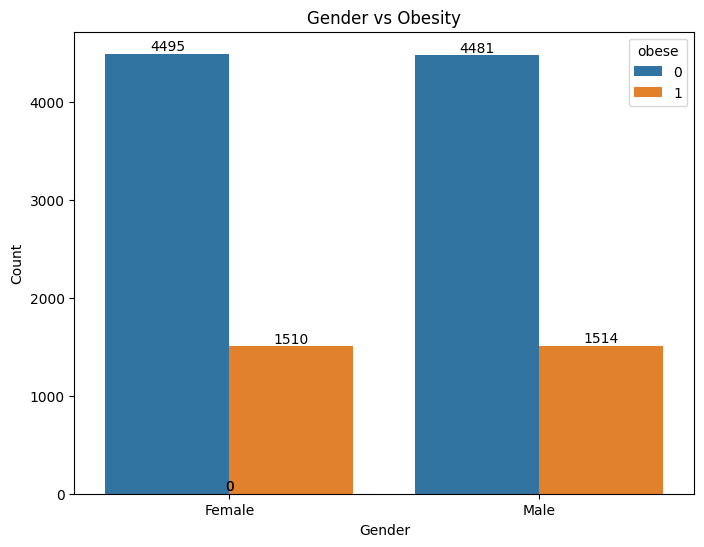

In [ ]:
# Gender vs obesity
plt.figure(figsize=(8,6))
count_plot= sns.countplot(x='gender', hue='obese', data=df)

for bar in count_plot.patches:
  height = bar.get_height()
  count_plot.text(x=bar.get_x() + bar.get_width()/2, y=height, s=f'{int(height)}', ha='center', va='bottom')

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender vs Obesity')
plt.show()

#Countplot showing the number of obese and non-obese individuals for each gender.

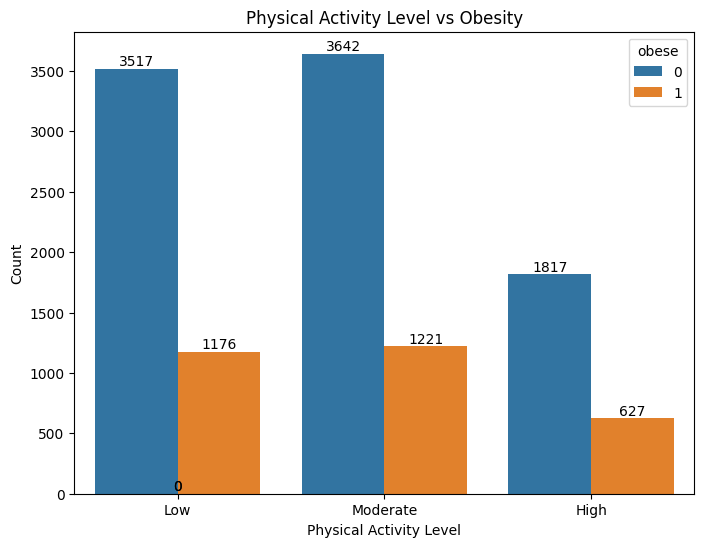

In [ ]:
# Activity level vs obesity
plt.figure(figsize=(8,6))
cnt_plt= sns.countplot(x='physical_activity_level', hue='obese', data=df)


for bar in cnt_plt.patches:
  height = bar.get_height()
  cnt_plt.text(x=bar.get_x() + bar.get_width()/2, y=height, s=f'{int(height)}', ha='center', va='bottom')

plt.xlabel('Physical Activity Level')
plt.ylabel('Count')
plt.title('Physical Activity Level vs Obesity')
plt.show()

#Countplot showing obesity distribution across different physical activity levels.

Step 7: Identify dependent variable for Supervised Learning

In [ ]:
df['obese'].value_counts()  #Counts the number of individuals in the dataset

,count
obese,
0,8976
1,3024


Step 8: Define X (Features) and Y (Target) variable

In [ ]:
X = df.drop(columns = ['person_id', 'obese', 'bmi'], errors = 'ignore')  #Dropped identifier personid and target columns.
Y = df['obese']

In [ ]:
print('Feature (X) ', X.shape)
print('Feature (Y) ', Y.shape)

Feature (X)  (12000, 10)
Feature (Y)  (12000,)


Here,

the features include Age, Gender, Height, Weight, Physical Activity Level, Daily Calorie Intake, Smoking Status, Alcohol Consumption, and Family History,

while the dependent variable is Obesity Risk.

Step 9: Transform Categorical Data for Regression

Since Logistic Regression requires numeric input, we need to convert categorical variables into numeric values.


In [ ]:
X = pd.get_dummies(X, drop_first=True)
#This converts categorical features in X into numeric values using one-hot encoding, dropping the first category to avoid redundancy.

X.head()

,age,height_cm,weight_kg,daily_calorie_intake,gender_Male,physical_activity_level_Low,physical_activity_level_Moderate,smoking_status_Smoker,alcohol_consumption_Moderate,family_history_obesity_Yes,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,56,164.3,86.3,2584,False,True,False,True,False,False,True,False,False
1,69,177.0,64.1,1706,True,False,True,False,True,False,False,False,False
2,46,151.8,94.0,2292,True,False,True,False,True,False,True,False,False
3,32,165.1,75.7,2655,True,False,False,False,True,False,False,True,False
4,60,172.3,83.9,2376,False,False,True,False,True,False,False,True,False


Step 10:  Create Logistic Regression Model

In [ ]:
model = LogisticRegression(max_iter= 1000)
#Without setting max_iter, the model was raising a 'maximum iterations reached' error. Increasing max_iter ensures the logistic regression converges.

model

LogisticRegression(max_iter=1000)

Step 11: Fit Model to Features and Target

In [ ]:
model.fit(X, Y)
#At this point, the model has learned the relationships between features and obesity risk.

LogisticRegression(max_iter=1000)

Step 12: Generate Predictions with the Model

In [ ]:
prediction = model.predict(X)
prediction[:20]

array([1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1])

These predictions accurately match the true obesity status for the dataset, indicating the model is performing correctly.

Step 13: Compute Prediction probability

In [ ]:
probability = model.predict_proba(X)
probability[:5]

array([[6.05283590e-04, 9.99394716e-01],
       [9.99975293e-01, 2.47070561e-05],
       [2.66749460e-06, 9.99997333e-01],
       [9.99661858e-01, 3.38142041e-04],
       [9.97815118e-01, 2.18488196e-03]])

In the predicted probabilities, each row shows [Not-Obese, Obese]. If the probability of Obese is greater than 0.5, the sample is classified as 1 (Obese); otherwise, it is classified as 0 (Not-Obese).

Step 14: Model Accuracy Measurement

In [ ]:
accuracy = accuracy_score(Y, prediction)
print('Accuracy: ', accuracy)

Accuracy:  1.0


**The model’s predictions are completely accurate, showing it can be trusted.**